<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Анализ" data-toc-modified-id="Анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Анализ</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Тестирование" data-toc-modified-id="Тестирование-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Тестирование</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Вывод</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах.   
Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.   
Необходимо построить модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Шаги:
1. Загрузить данные и выполнить их ресемплирование по одному часу
2. Проанализировать данные.
3. Обучить разные модели с различными гиперпараметрами.   
    Сделать тестовую выборку размером 10% от исходных данных.
4. Проверить данные на тестовой выборке и сделать выводы.

Данные лежат в файле `taxi.csv`.<br>
Количество заказов находится в столбце `num_orders` (от англ. *number of orders*, «число заказов»).

In [5]:
!pip install -r requirements.txt

In [6]:
# библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import phik

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor

# визуал
import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns=None

# константы
TEST_SIZE = 0.1
RANDOM_STATE = 42

## Подготовка

Необходимо загрузить данные и выполнить их ресемплирование по одному часу

In [7]:
df = (pd.read_csv('./data/taxi.csv', 
                  parse_dates=[0], # парсим дату
                  index_col=[0]) # убираем её в индекс
        .resample('1H').sum()) # агрегируем по 1 часу

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


## Анализ 

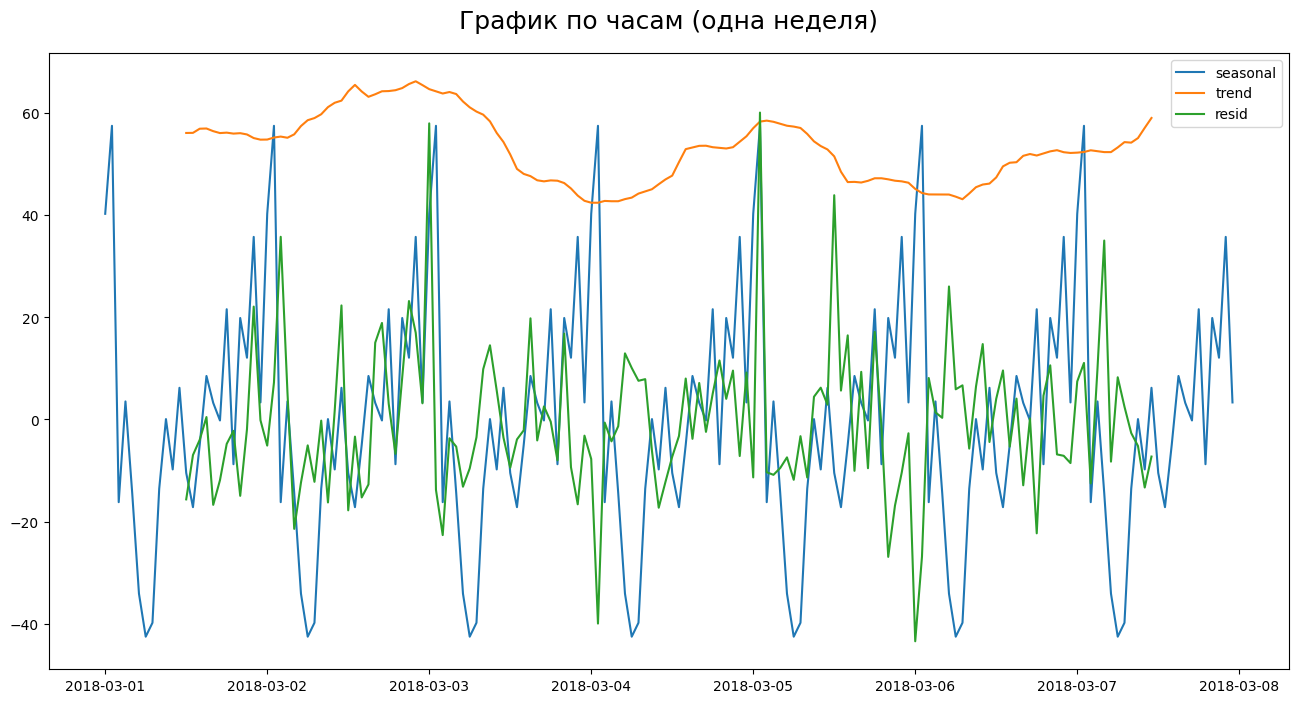

In [8]:
# ограничим выборку
decomposed = seasonal_decompose(df['2018-03-01':'2018-03-07'])

plt.figure(figsize=(16,8))
plt.plot(decomposed.seasonal, label='seasonal')
plt.plot(decomposed.trend, label='trend')
plt.plot(decomposed.resid, label='resid')
plt.title('График по часам (одна неделя)', fontsize=18, pad=18)
plt.legend()
plt.show()

Наблюдаем нисходящий тренд в первую неделю, но важнее тут то, что в ряде наблюдаем явную цикличность (суточную сезонность). 

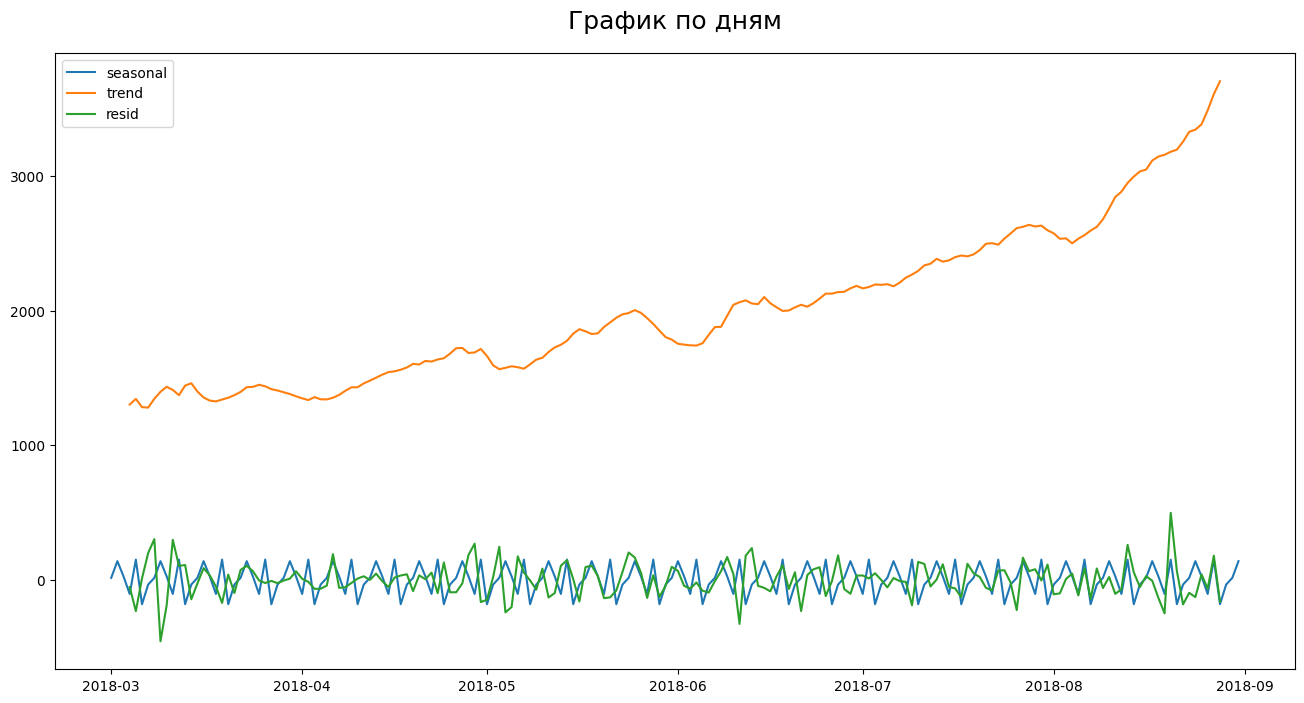

In [9]:
decomposed = seasonal_decompose(df.resample('1D').sum())

plt.figure(figsize=(16,8))
plt.plot(decomposed.seasonal, label='seasonal')
plt.plot(decomposed.trend, label='trend')
plt.plot(decomposed.resid, label='resid')
plt.title('График по дням', fontsize=18, pad=18)
plt.legend()
plt.show()

Судя по дополнительному графику (по дням) количество заказов растёт от месяца к месяцу (с небольшими провалами).  
Видимо количество людей, которое используют этот аэропорт, растёт. 

Сгенерируем дополнительные признаки (год и месяц делать не будем, т.к. год один, а месяцы не повторяются):

In [10]:
# генерируем признаки
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek
df['hour'] = df.index.hour

# генерируем скользящие средние
df['roll_mean_6'] = df['num_orders'].shift(1).rolling(6).mean()
df['roll_mean_12'] = df['num_orders'].shift(1).rolling(12).mean()

# дает возможность модели смотреть назад во времени
df['lag_1'] = df['num_orders'].shift(1)
df['lag_2'] = df['num_orders'].shift(2)
df['lag_23'] = df['num_orders'].shift(23)
df['lag_24'] = df['num_orders'].shift(24)
df['lag_47'] = df['num_orders'].shift(47)
df['lag_48'] = df['num_orders'].shift(48)

# удалим строки с пропусками, которые образовались в лагах
df.dropna(inplace=True)

df.head()

,num_orders,day,dayofweek,hour,roll_mean_6,roll_mean_12,lag_1,lag_2,lag_23,lag_24,lag_47,lag_48
datetime,,,,,,,,,,,,
2018-03-03 00:00:00,163,3,5,0,87.166667,72.666667,72.0,119.0,120.0,90.0,85.0,124.0
2018-03-03 01:00:00,108,3,5,1,99.500000,83.250000,163.0,72.0,75.0,120.0,71.0,85.0
2018-03-03 02:00:00,25,3,5,2,109.333333,88.500000,108.0,163.0,64.0,75.0,66.0,71.0
2018-03-03 03:00:00,64,3,5,3,98.000000,86.916667,25.0,108.0,20.0,64.0,43.0,66.0
2018-03-03 04:00:00,44,3,5,4,91.833333,87.333333,64.0,25.0,11.0,20.0,6.0,43.0


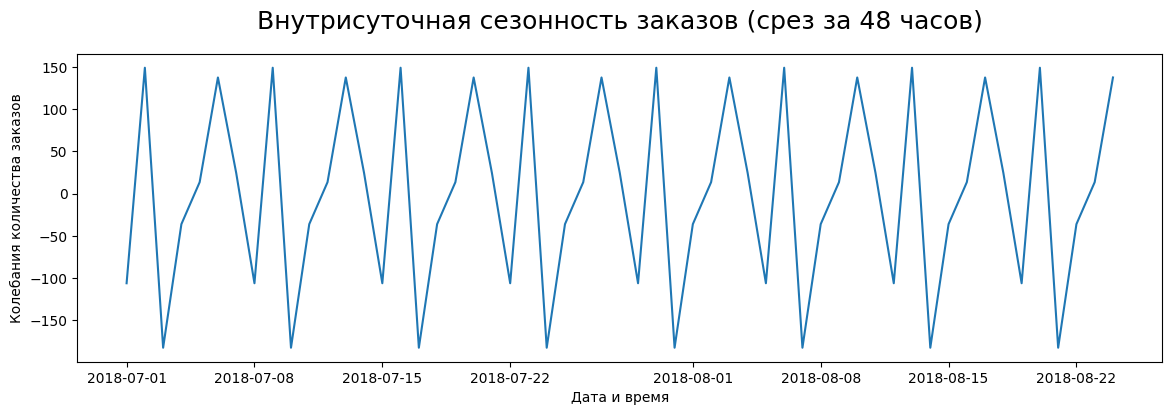

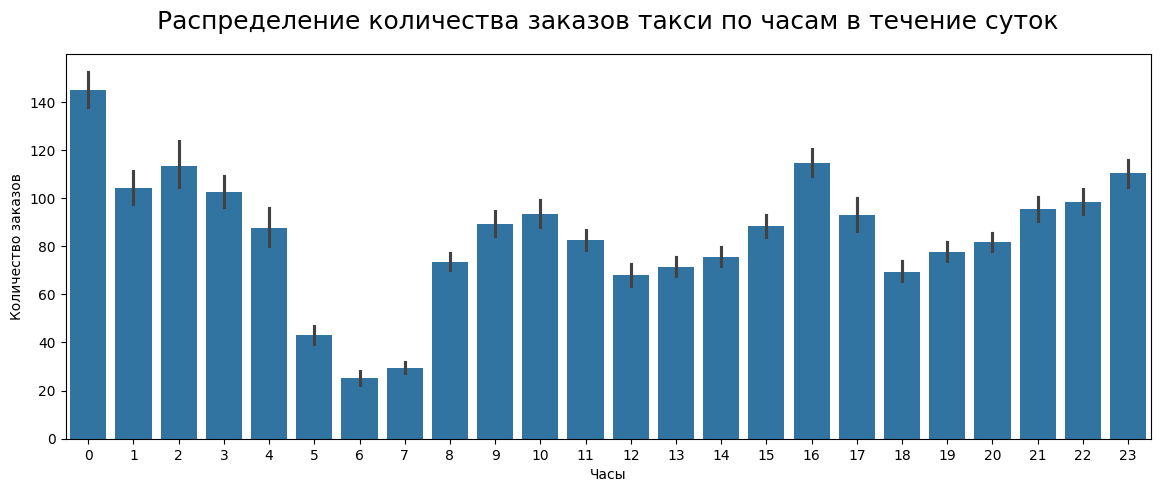

In [11]:
# увеличим масштаб графика сезонности (срез за 2 суток)
plt.figure(figsize=(14, 4))
plt.plot(decomposed.seasonal['2018-07-01':'2018-08-24'])
plt.title('Внутрисуточная сезонность заказов (срез за 48 часов)', fontsize=18, pad=18)
plt.xlabel('Дата и время')
plt.ylabel('Колебания количества заказов')
plt.show()

# распределение заказов по часам
plt.figure(figsize=(14, 5))
sns.barplot(data=df, x='hour', y='num_orders')
plt.title('Распределение количества заказов такси по часам в течение суток', fontsize=18, pad=18)
plt.xlabel('Часы')
plt.ylabel('Количество заказов')
plt.show()

На графике сезонности 48 часов мы видим, что пики повторяют друг друга,   
а значит модель сможет найти взаимосвязь между временем суток и количеством заказов.

На втором графике (суточная сезонность) мы можем увидеть в целом в какое время больше всего заказов:  
количество заказов увеличивается ночью: начинает плавно расти с 18 часов и достигает пика к полуночи,  
затем плавно снижается до своего минимума в 6 часов утра.

Взглянем на корреляцию признаков:

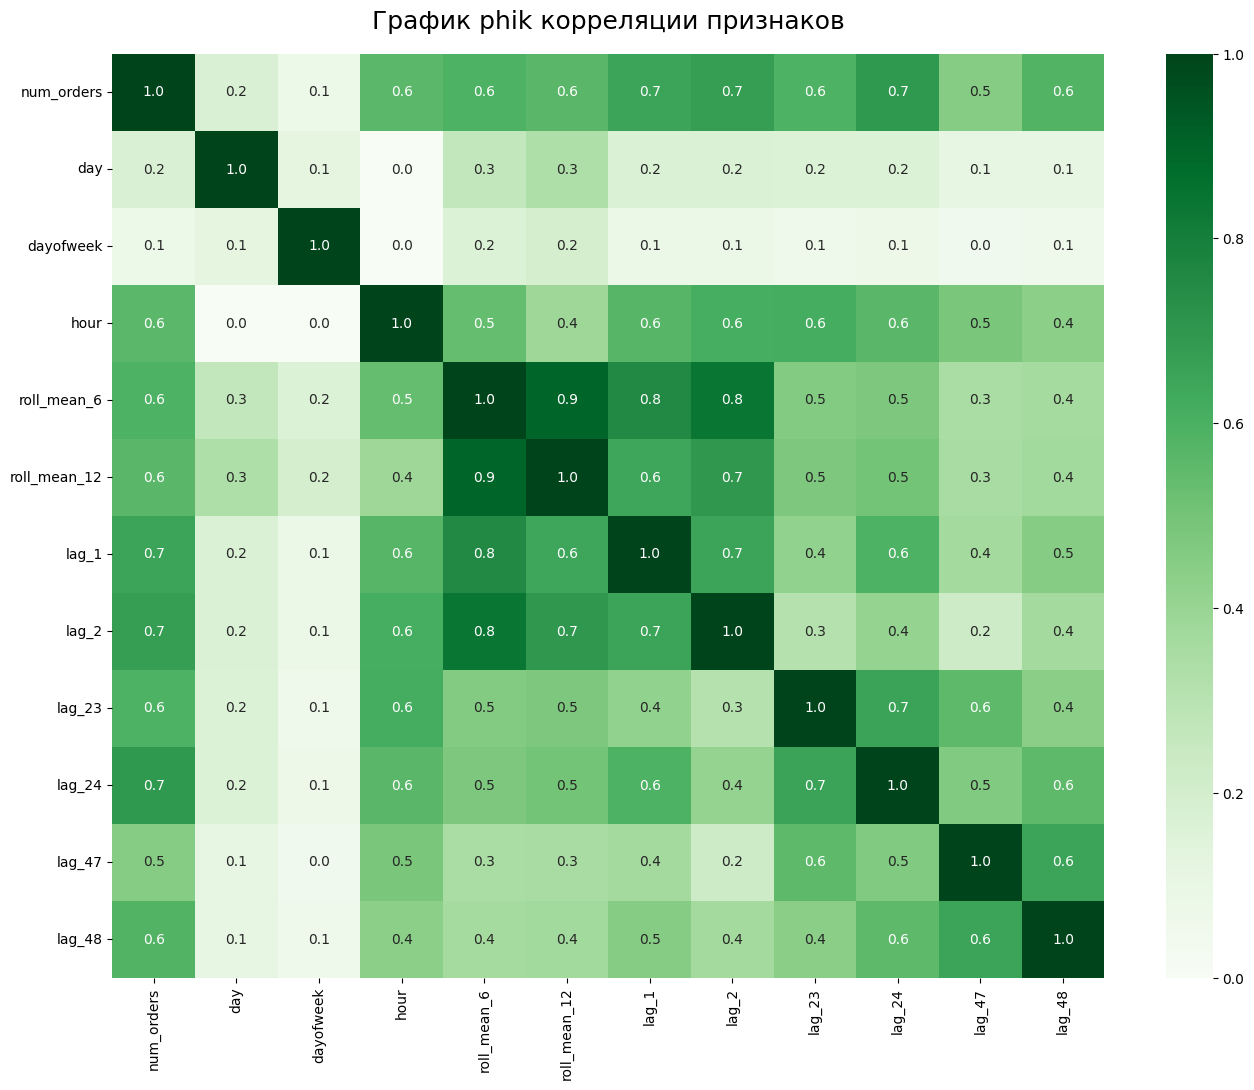

In [12]:
phik_matrix = df.phik_matrix(interval_cols=df.select_dtypes(include='number').columns)

plt.figure(figsize=(16,12))
sns.heatmap(phik_matrix, annot=True, fmt='.1f', cmap='Greens')
plt.title('График phik корреляции признаков', fontsize=18, pad=18)
plt.show()

С целевым признаков хорошо коррелируют все признаки, кроме дня и дня недели.

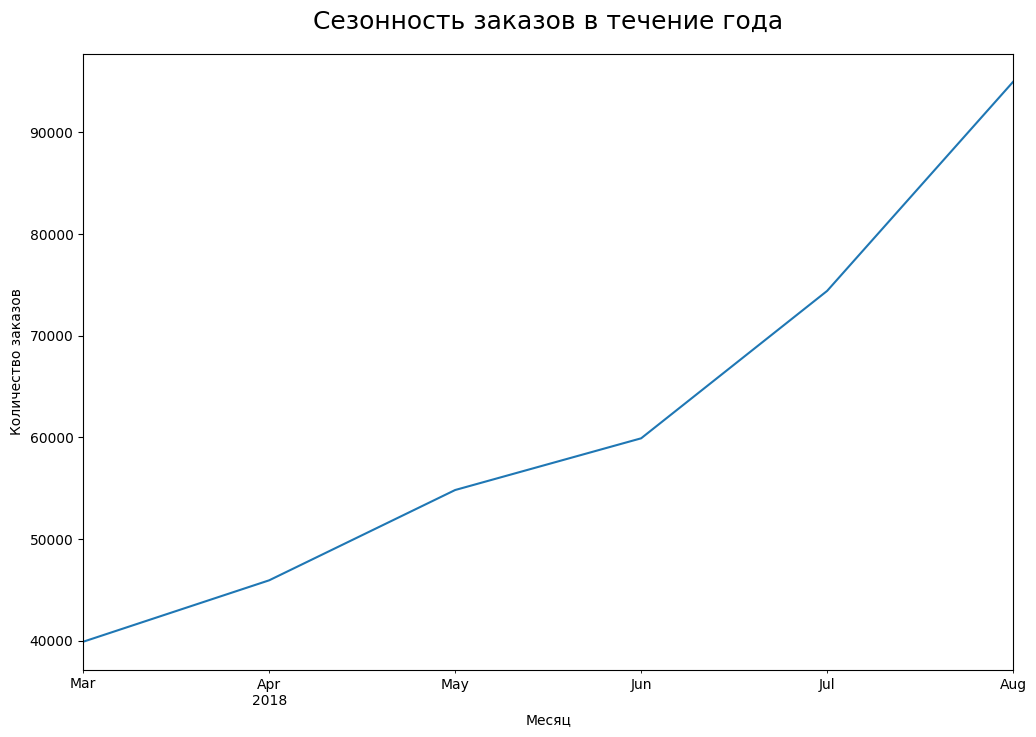

In [13]:
# ресэмпл по месяцу
data_month = df.resample('1M').sum()

plt.figure(figsize=(12,8))
data_month['num_orders'].plot()
plt.title('Сезонность заказов в течение года', fontsize=18, pad=18)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

Наблюдается плавный рост числа заказов до июня, после чего рост ускоряется до конца августа.

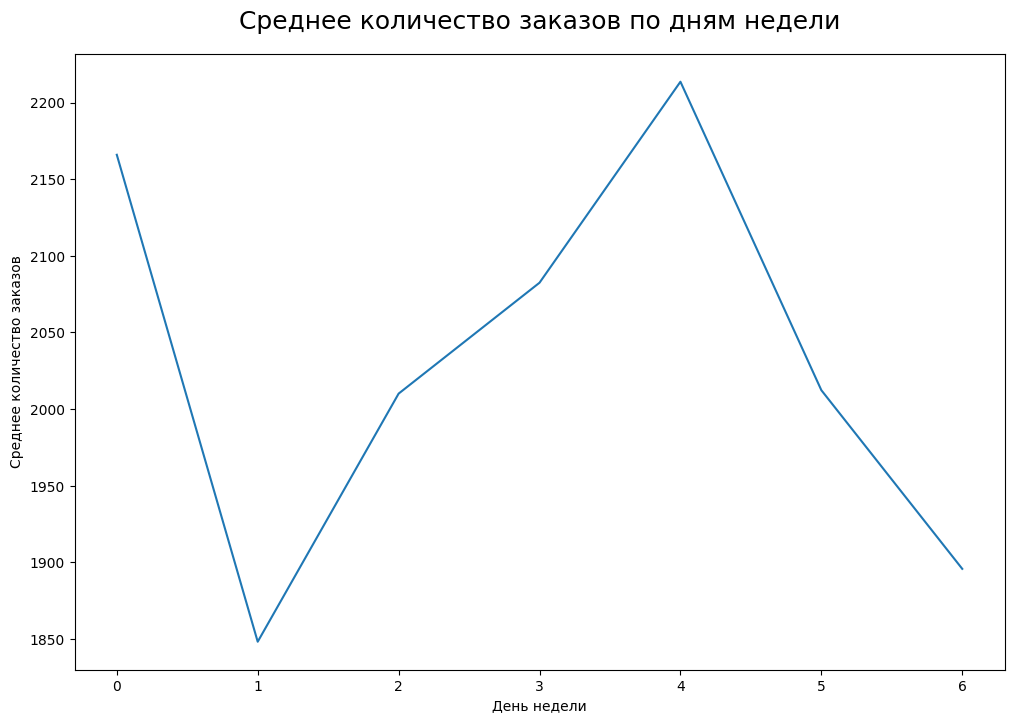

In [14]:
data_day = df.resample('1D').sum()

plt.figure(figsize=(12,8))
data_day.groupby(data_day.index.dayofweek)['num_orders'].mean().plot()
plt.title('Среднее количество заказов по дням недели', fontsize=18, pad=18)
plt.xlabel('День недели')
plt.ylabel('Среднее количество заказов')
plt.show()

В среднем больше всего заказов по понедельниками и пятницам и минимально во вторник и воскресенье.  
Предположим, что сотрудники аэропорта на такси уезжают в пятницу и приезжают в понедельник.

Дополнительно, с помощью теста Дики-Фуллера, проверим стационарность ряда:

In [15]:
result = adfuller(df['num_orders'])

p_value = result[1]

if p_value > 0.05: 
    print('Нулевая гипотеза верна: ряд нестационарный')
else:
    print('Альтернативная гипотеза верна: ряд стационарный')

Альтернативная гипотеза верна: ряд стационарный


## Обучение

Необходимо обучить разные модели с различными гиперпараметрами.   
Сделать тестовую выборку размером 10% от исходных данных (TEST_SIZE=0.1). 

Для этой задачи мы используем: 
- LinearRegression
- RandomForest
- CatBoost

In [16]:
# выделяем таргет и признаки
X = df.drop(columns=['num_orders'])
y = df['num_orders']

# делим данные без перемешивания
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, 
                                                    test_size=TEST_SIZE)

# сетка моделей и параметров
models = {
    
    'LinearRegression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False]
        }
    },
    
    'RandomForest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        }
    },
    
    'CatBoost': {
        'model': CatBoostRegressor(verbose=0),
        'params': {
            'iterations': [300, 500, 800],
            'depth': [4, 6, 8],
            'learning_rate': [0.03, 0.05, 0.1]
        }
    }
}

models

{'LinearRegression': {'model': LinearRegression(),
  'params': {'fit_intercept': [True, False]}},
 'RandomForest': {'model': RandomForestRegressor(),
  'params': {'n_estimators': [100, 200],
   'max_depth': [5, 10, None],
   'min_samples_split': [2, 5]}},
 'CatBoost': {'model': <catboost.core.CatBoostRegressor at 0x18a67997f20>,
  'params': {'iterations': [300, 500, 800],
   'depth': [4, 6, 8],
   'learning_rate': [0.03, 0.05, 0.1]}}}

In [17]:
%%time 

results = []
best_model = None
best_score = float('-inf')  # Начинаем с минус бесконечности

for model_name, model_info in models.items():
    print(f'Начинаю обучение: {model_name}')
    
    tscv = TimeSeriesSplit(n_splits=5)

    grid = GridSearchCV( # можно использовать randomized в будущем
        model_info['model'],
        model_info['params'],
        cv=tscv,  # делит данные так, что будущие значения всегда в тесте
        scoring='neg_mean_squared_error',
        n_jobs=-1,
#         n_iter=5,
#         random_state=RANDOM_STATE
    )
    
    grid.fit(X_train, y_train)
    
    results.append({
        'Model': model_name,
        'Best RMSE': np.sqrt(abs(grid.best_score_)),
        'Best Params': grid.best_params_
    })
    
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
    
print('Обучение завершено', end='\n\n')

results = pd.DataFrame(results).sort_values(by='Best RMSE')

results

Начинаю обучение: LinearRegression
Начинаю обучение: RandomForest
Начинаю обучение: CatBoost
Обучение завершено

CPU times: total: 6.72 s
Wall time: 45 s


,Model,Best RMSE,Best Params
2,CatBoost,24.018014,"{'depth': 6, 'iterations': 300, 'learning_rate..."
1,RandomForest,24.680963,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
0,LinearRegression,25.116934,{'fit_intercept': False}


Лучшей моделью оказался CatBoost, которому не помеха мультиколлинеарность,   
которая могла появиться, благодаря генерации значительного объема признаков.

## Тестирование

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48

In [18]:
# предсказываем лучшей моделью
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'RMSE: {rmse:.2f}')

RMSE: 41.34


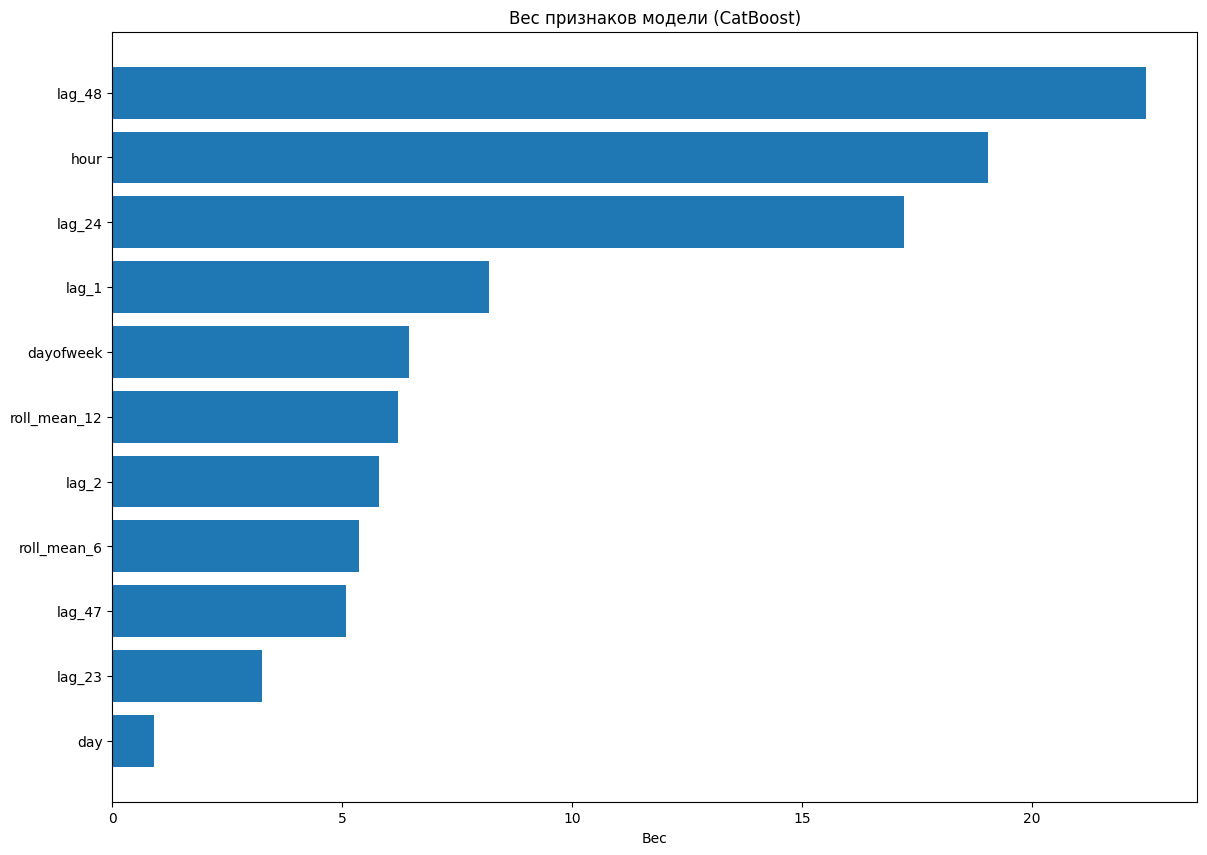

In [19]:
importances = best_model.feature_importances_
features = X_train.columns

importance_df = (pd.DataFrame({'feature': features,
                               'importance': importances})
                   .sort_values('importance', ascending=False))

plt.figure(figsize=(14,10))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title('Вес признаков модели (CatBoost)')
plt.xlabel('Вес')
plt.show()

Самым важным признаком для модели оказался `lag_48`,`lag_24`, `hour`, `lag_1` и что удивительно - `dayofweek`. <br>
С точки зрения логики понятно, что в зависимости ото дня недели количество заказов может меняться,  
но на phik матрице корреляции между целевым признаком и днем недели практически не было (0.1).  

Получается, чтобы предсказывать, модели важно заглядывать в это же время на день назад, <br>
также необходимо видеть на несколько часов назад, знать сколько сейчас время и какой день недели,  <br> 
также не лишний здесь признак скользящего среднего за 12 часов.  

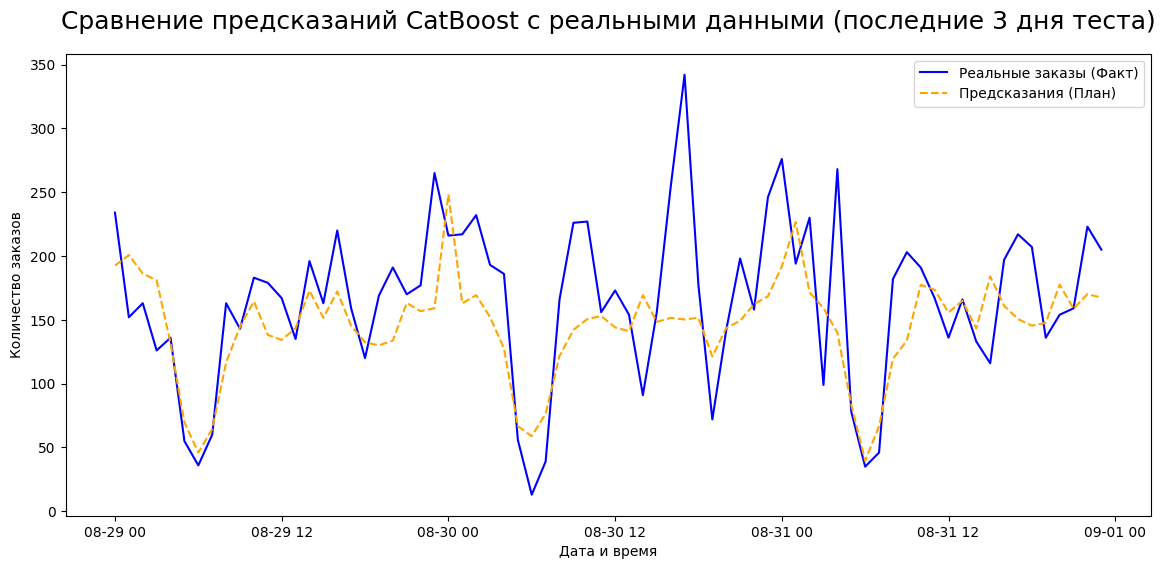

In [20]:
# Сравнение предсказаний и реальных данных (План vs Факт)
# Берем последние 72 часа для наглядности
plt.figure(figsize=(14, 6))
plt.plot(y_test.index[-72:], y_test[-72:], label='Реальные заказы (Факт)', color='blue')
plt.plot(y_test.index[-72:], y_pred[-72:], label='Предсказания (План)', color='orange', linestyle='--')
plt.title('Сравнение предсказаний CatBoost с реальными данными (последние 3 дня теста)', fontsize=18, pad=18)
plt.xlabel('Дата и время')
plt.ylabel('Количество заказов')
plt.legend()
plt.show()

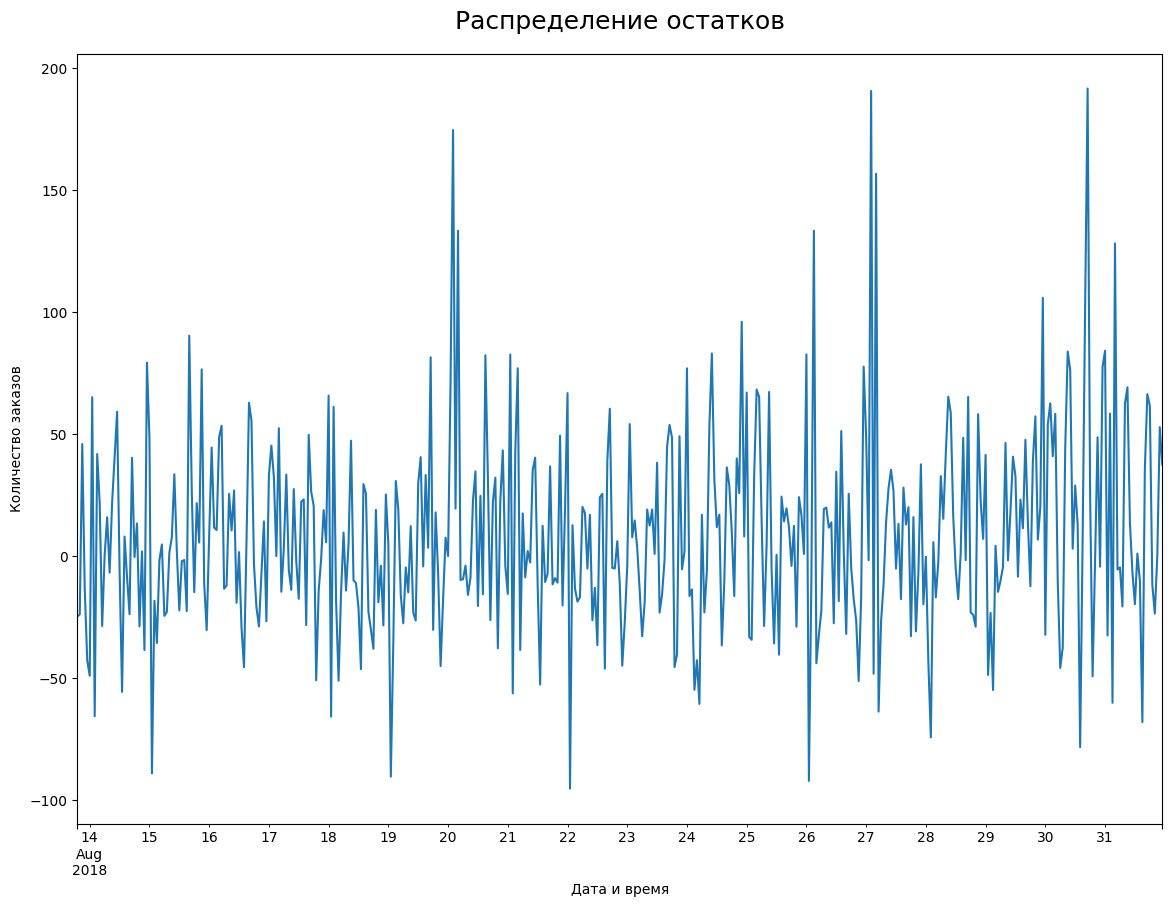

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(14,10))
residuals.plot()
plt.title('Распределение остатков', fontsize=18, pad=18)
plt.xlabel('Дата и время')
plt.ylabel('Количество заказов')
plt.show()

Остатки модели распределены вокруг нулевого значения, чуть больше выбросы выше нуля.

Есть ощущение, что к концу временного ряда разброс остатков несколько увеличивается.   
Возможно это указывает на то, что данные становятся менее предсказуемыми,   
и модель хуже справляется с прогнозированием на последних наблюдениях.

Вероятно из-за этого ошибка на тесте выше, чем на тренировочных данных.

## Вывод

Модель достаточно хорошо предсказывает общее количество заказов: RMSE 41,34 при заданном пороге в 48,   
правда зачастую модель не попадает в пики. Это значит, что модель не переобучилась,  
но конкретно в этой задаче, думаю, ей можно было бы дать переобучиться, чтобы сделать прогноз более точным,   
т.к. каких-либо резких изменений в этом бизнесе не предполагается (в виде новых данных).